In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("D:/Documentos/Projects_DS/datasets/students performance/StudentPerformanceFactors.csv")

In [3]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [6]:
#Obtener porcentajes de Nan
missing = df.isna().sum()
perc_missing = (df.isna().mean()*100).round(2)
resumen_nan = pd.DataFrame({
    'Valores faltantes': missing,
    'porcentaje': perc_missing
})
resumen_nan

,Valores faltantes,porcentaje
Hours_Studied,0,0.00
Attendance,0,0.00
Parental_Involvement,0,0.00
Access_to_Resources,0,0.00
Extracurricular_Activities,0,0.00
Sleep_Hours,0,0.00
Previous_Scores,0,0.00
Motivation_Level,0,0.00
Internet_Access,0,0.00
Tutoring_Sessions,0,0.00


In [7]:
### Limpieza de NA. son insignificantes comparado con el total
df = df.dropna(subset=['Teacher_Quality'])
df = df.dropna(subset=['Distance_from_Home'])
df = df.dropna(subset=['Parental_Education_Level'])
#Extracurricular_Activities no tiene datos son todos 0, eliminarla

In [8]:
df.sample(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
3531,31,69,Medium,Low,Yes,6,80,Low,Yes,4,Medium,Medium,Public,Negative,2,No,College,Near,Male,68
3953,23,86,High,Medium,No,7,54,Low,Yes,2,Medium,Medium,Public,Negative,2,Yes,High School,Near,Female,67
6537,24,78,High,High,Yes,8,87,Medium,Yes,2,Medium,Medium,Public,Neutral,3,No,High School,Near,Male,71
5718,23,93,Medium,Low,Yes,9,94,High,Yes,2,Medium,Low,Private,Negative,3,No,High School,Moderate,Female,70
496,14,89,High,High,Yes,4,73,Medium,Yes,2,Medium,High,Public,Negative,3,No,College,Near,Male,70
4651,24,86,Medium,High,Yes,9,69,High,Yes,1,Medium,High,Public,Neutral,3,No,Postgraduate,Near,Male,72
6138,20,93,Medium,Low,No,8,63,Medium,Yes,0,Low,High,Public,Negative,3,No,High School,Moderate,Male,66
2582,20,70,Low,Medium,No,7,73,Medium,Yes,0,Low,Medium,Public,Negative,5,No,High School,Near,Female,62
3929,21,99,Medium,High,No,7,51,High,Yes,2,Medium,Low,Private,Neutral,2,No,Postgraduate,Near,Female,72
3698,26,84,Medium,Medium,No,8,76,Medium,Yes,5,Medium,High,Public,Neutral,2,No,High School,Moderate,Male,71


In [9]:
#ANalisis exploratorio
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


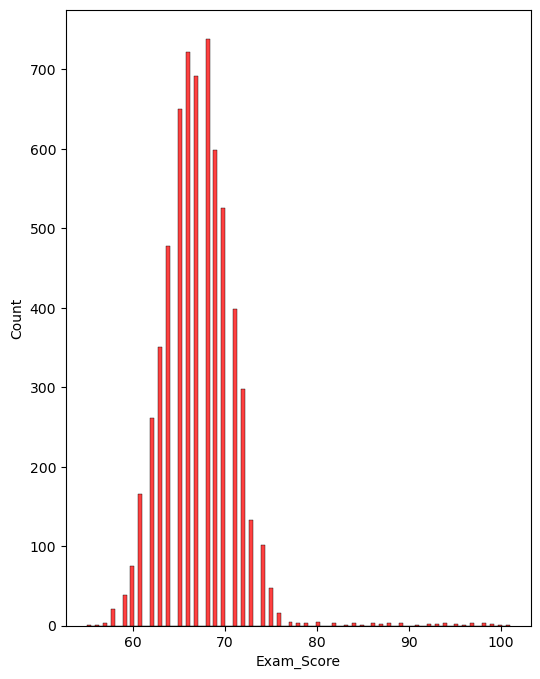

In [10]:
plt.figure(figsize=(6,8))
sns.histplot(df, x='Exam_Score', color='red')
plt.show()

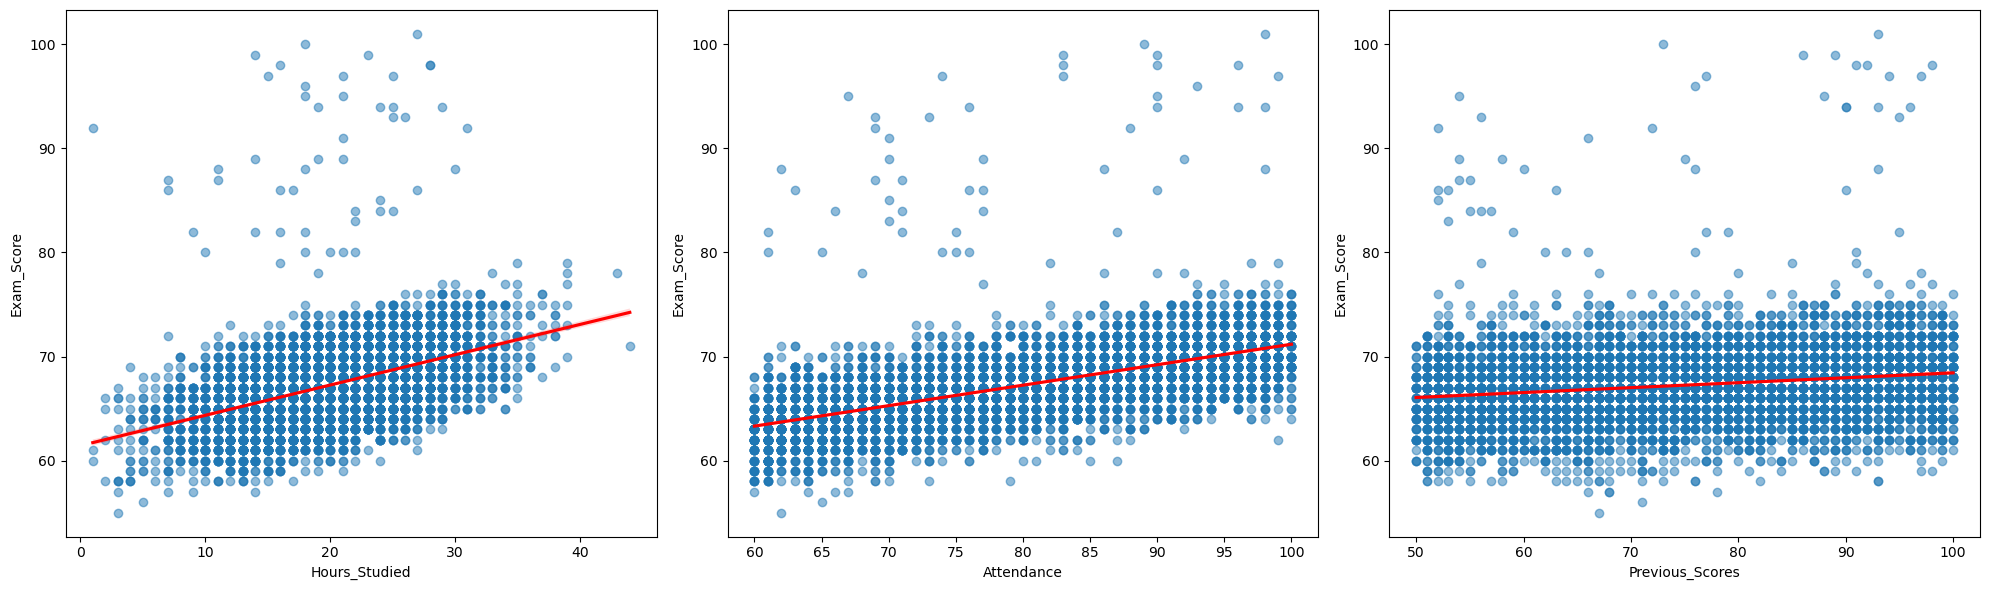

In [11]:
variables_x = ['Hours_Studied', 'Attendance', 'Previous_Scores'] # Cambia estos nombres por los tuyos

# 2. Crea el "lienzo" con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(20, 6)) # figsize controla el tamaño total

# 3. Bucle para dibujar cada uno
for i, col in enumerate(variables_x):
    sns.regplot(
        data=df,
        x=col,            # Aquí va cambiando la variable en cada vuelta
        y='Exam_Score',
        scatter_kws={'alpha': 0.5},
        line_kws={'color': 'red'},
        ax=axes[i]        # Le decimos en cuál de los 3 huecos dibujarse
    )

plt.tight_layout() # Ajusta los espacios para que no se vean apretados
plt.show()

In [12]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000
mean,19.977109,80.020853,7.034964,75.066165,1.495296,2.972719,67.252117
std,5.985460,11.550723,1.468033,14.400389,1.233984,1.028926,3.914217
min,1.000000,60.000000,4.000000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.000000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.000000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.000000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.000000,100.000000,8.000000,6.000000,101.000000


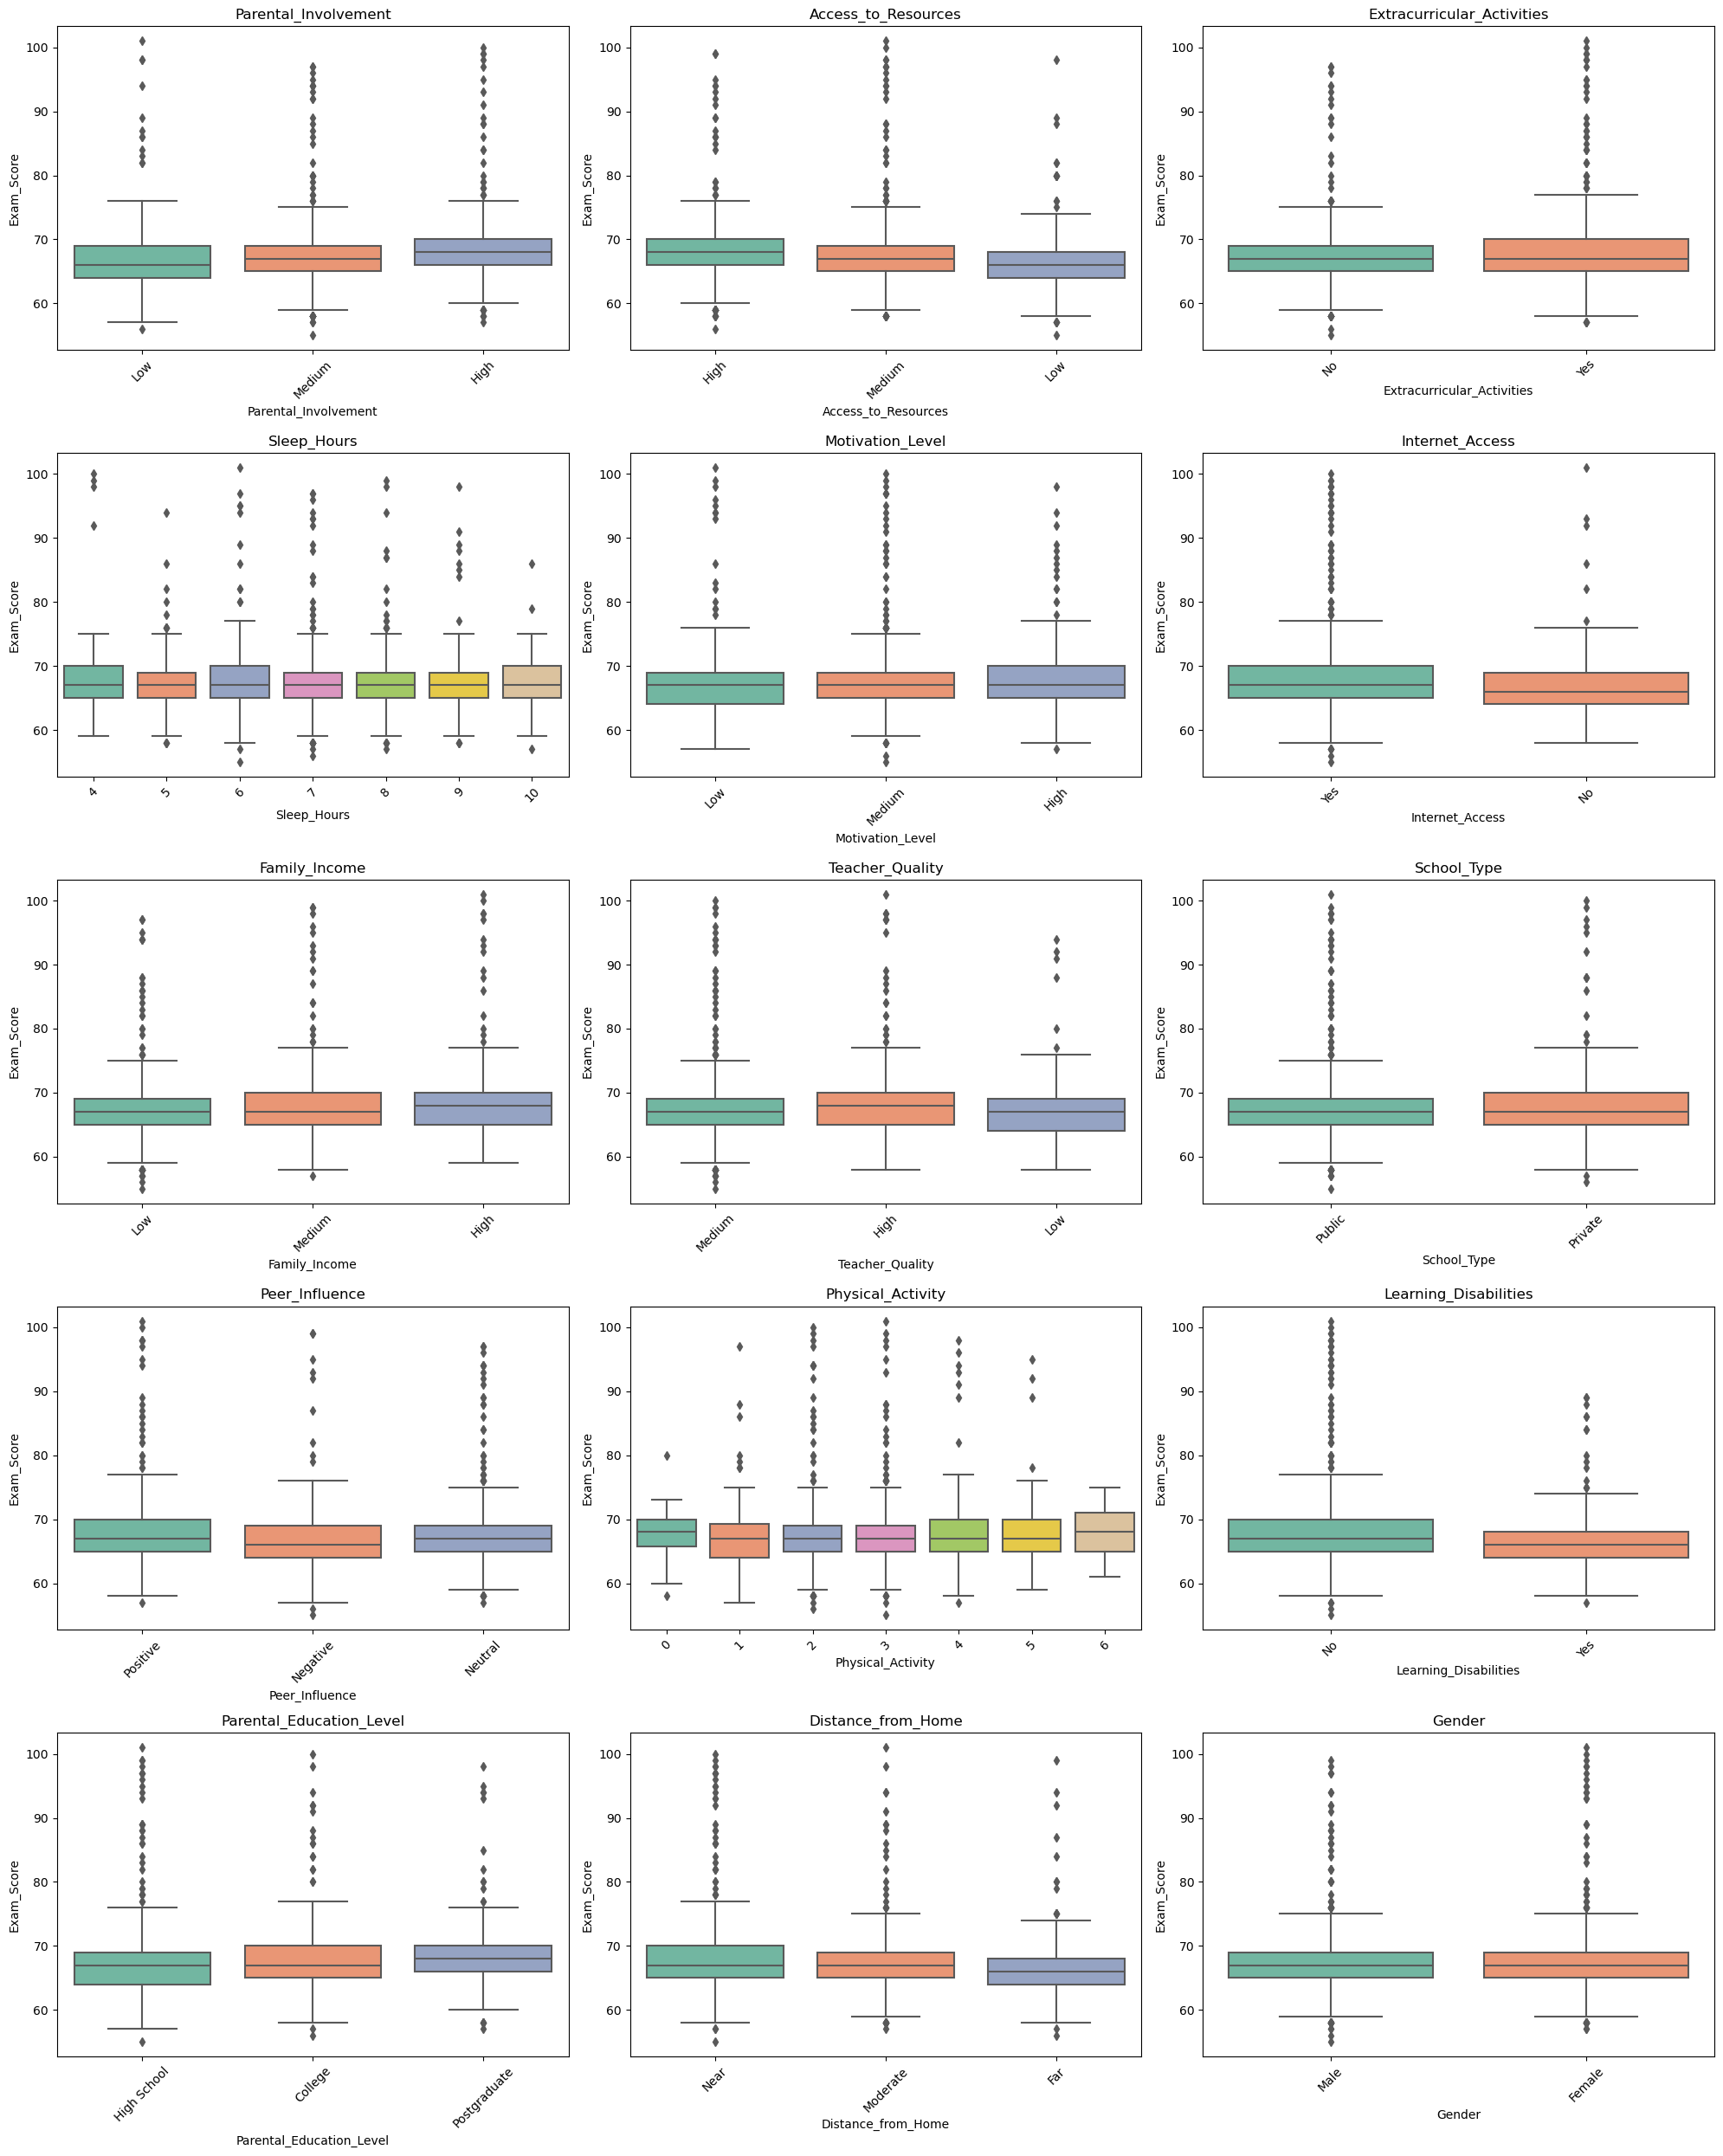

In [13]:
import math

# Tu lista de variables
variables_cualitativas = [
    'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities',
    'Sleep_Hours', 'Motivation_Level', 'Internet_Access', 'Family_Income',
    'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity',
    'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender'
]

# 1. Calcular cuántas filas se necesitan (15 vars / 3 cols = 5 filas)
n_cols = 3
n_rows = math.ceil(len(variables_cualitativas) / n_cols)

# 2. Creamos el lienzo grande. Aumentamos el alto (figsize) para que entren 5 filas
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 25))

# 3. "Aplanamos" la matriz de ejes para poder recorrerla con un solo índice (0 a 14)
axes = axes.flatten()

# 4. Bucle
for i, col in enumerate(variables_cualitativas):
    # Usamos BOXPLOT: El mejor para ver distribución de notas por categoría
    sns.boxplot(
        data=df, 
        x=col, 
        y='Exam_Score', 
        ax=axes[i],
        palette="Set2" # Opcional: para darle colores distintos
    )
    
    # Ajustes estéticos para cada grafiquito
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45) # Rotamos texto si es muy largo

# 5. Borrar los huecos vacíos si sobran (por si tu lista no fuera múltiplo de 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Fundamental para que no se monten los textos
plt.show()

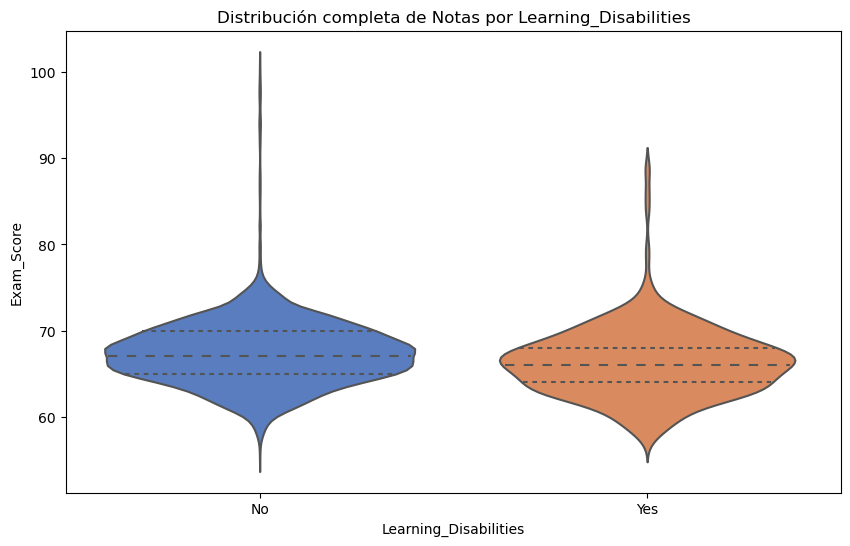

In [14]:
#Ver especificamente una variable
variable_dudosa = 'Learning_Disabilities' 

plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df, 
    x=variable_dudosa, 
    y='Exam_Score', 
    palette="muted",
    inner="quartile" # Esto dibuja las líneas de la mediana y cuartiles dentro
)
plt.title(f'Distribución completa de Notas por {variable_dudosa}')
plt.show()

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline


In [16]:
#Definicion de variables a utilizar
X = df[['Extracurricular_Activities', 'Internet_Access' , 'Learning_Disabilities','Distance_from_Home', 
'Sleep_Hours', 'Physical_Activity', 'Hours_Studied', 'Attendance']]
y = df['Exam_Score']


In [17]:
#Definir las categoricas
categoricas = ['Extracurricular_Activities', 'Internet_Access' , 'Learning_Disabilities','Distance_from_Home', 
               'Physical_Activity', 'Hours_Studied', 'Attendance']

# 2. Construir el Preprocesador (ColumnTransformer)
# ---------------------------------------------------------
# Esto le dice: "A las categóricas hazles OneHot, y al resto (passthrough) déjalas como están"
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categoricas)
    ],
    remainder='passthrough'  # IMPORTANTE: Esto conserva las variables numéricas (Hours_Studied, etc.)
)

In [19]:
# 3. Crear el Pipeline
# ---------------------------------------------------------
# Unimos los pasos: Primero preprocesa, luego entrena el modelo.
# Para regresion (numero 0-100): RandomForestRegressor
# Para clasificar (Aprobado/Reprobado): RandomForestClassifier.
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regresion', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [20]:
# 4. Separar datos y Entrenar
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Al hacer fit, el pipeline se encarga de transformar X_train automáticamente
model_pipeline.fit(X_train, y_train)

# 5. Evaluar
# ---------------------------------------------------------
score = model_pipeline.score(X_test, y_test)
print(f"R2 Score del modelo: {score:.4f}")

R2 Score del modelo: 0.3783


R2 en Entrenamiento (Lo que memorizó): 0.9144
R2 en Test (Lo que predice realmente): 0.3783


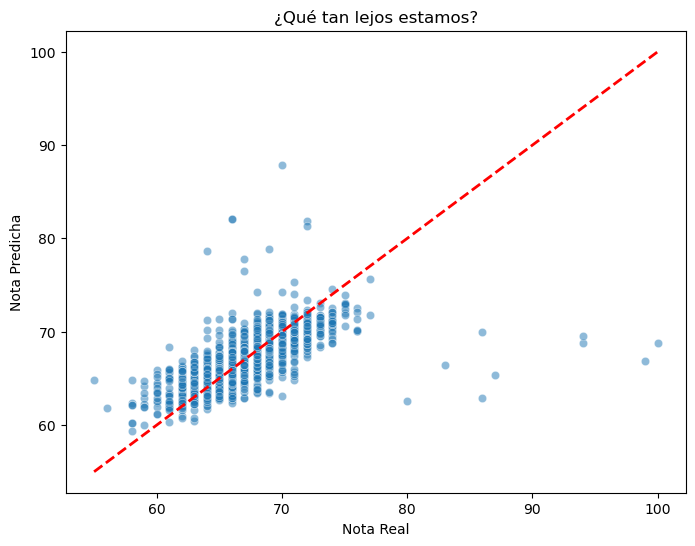

In [21]:
# 1. Calcular el score en Entrenamiento (Train) y en Prueba (Test)
train_score = model_pipeline.score(X_train, y_train)
test_score = model_pipeline.score(X_test, y_test)

print(f"R2 en Entrenamiento (Lo que memorizó): {train_score:.4f}")
print(f"R2 en Test (Lo que predice realmente): {test_score:.4f}")

# 2. Graficamos la Realidad vs la Predicción
y_pred = model_pipeline.predict(X_test)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Línea ideal
plt.xlabel('Nota Real')
plt.ylabel('Nota Predicha')
plt.title('¿Qué tan lejos estamos?')
plt.show()

In [22]:
#El modelo en entrenamiento memorizo los resultados y al momento del test fallo. SOBREAJUSTE

In [23]:
#MEJORAR
# Modificar Pipeline actual en la parte del 'classifier'
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestRegressor(
        n_estimators=200,      # Más árboles suele ayudar a estabilizar
        max_depth=10,          # IMPORTANTE: No le dejes hacer preguntas infinitas. Solo 10 niveles.
        min_samples_leaf=10,   # IMPORTANTE: Cada "hoja" final debe tener al menos 10 alumnos. 
                               # Esto evita que cree una regla solo para "Juanito el que vive lejos".
        max_features='sqrt',   # Mira menos variables a la vez para evitar depender de una sola.
        random_state=42
    ))
])

# Vuelve a entrenar y evalúa
model_pipeline.fit(X_train, y_train)

print(f"Nuevo R2 Train: {model_pipeline.score(X_train, y_train):.4f}")
print(f"Nuevo R2 Test: {model_pipeline.score(X_test, y_test):.4f}")

Nuevo R2 Train: 0.2380
Nuevo R2 Test: 0.2305


In [24]:
#XGBOOST

from sklearn.ensemble import GradientBoostingRegressor

# Modificamos el Pipeline para usar GradientBoosting
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingRegressor(
        n_estimators=200, 
        learning_rate=0.05, # Aprende despacio para no memorizar (clave en boosting)
        max_depth=4,        # Árboles pequeños, el boosting prefiere "expertos locales"
        random_state=42
    ))
])

model_pipeline.fit(X_train, y_train)

print(f"Gradient Boosting R2 Train: {model_pipeline.score(X_train, y_train):.4f}")
print(f"Gradient Boosting R2 Test: {model_pipeline.score(X_test, y_test):.4f}")

Gradient Boosting R2 Train: 0.5484
Gradient Boosting R2 Test: 0.4028


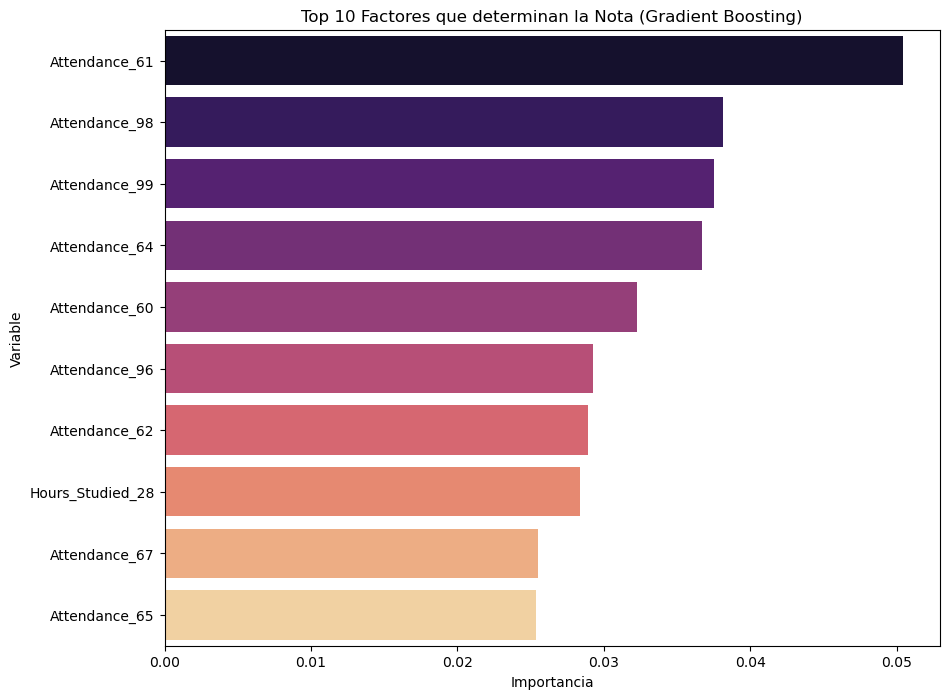

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recuperamos el modelo y el preprocesador del pipeline
modelo_final = model_pipeline.named_steps['classifier']
preprocesador = model_pipeline.named_steps['preprocessor']

# 2. Obtenemos los nombres de las columnas categóricas (las que pasaron por OneHot)
# Accedemos al transformador 'cat' (así lo llamamos en el ColumnTransformer)
ohe = preprocesador.named_transformers_['cat']
nombres_cat = ohe.get_feature_names_out(categoricas)

# 3. Obtenemos los nombres de las columnas numéricas
# Son las que NO estaban en categorical_features
nombres_num = [col for col in X_train.columns if col not in categoricas]

# 4. Unimos todos los nombres en el orden correcto
nombres_todos = np.concatenate([nombres_cat, nombres_num])

# 5. Creamos el DataFrame de Importancia
importancias = pd.DataFrame({
    'Variable': nombres_todos,
    'Importancia': modelo_final.feature_importances_
}).sort_values('Importancia', ascending=False)

# 6. Graficamos el Top 10
plt.figure(figsize=(10, 8))
sns.barplot(data=importancias.head(10), x='Importancia', y='Variable', palette='magma')
plt.title('Top 10 Factores que determinan la Nota (Gradient Boosting)')
plt.show()

In [26]:
modelo_final.feature_importances_

array([5.65864623e-03, 5.89191071e-03, 8.64881821e-03, 1.04720172e-02,
       9.42457967e-03, 8.38568775e-03, 3.72813121e-03, 6.09886032e-03,
       1.53797010e-02, 4.28665016e-03, 6.73553434e-04, 4.54372225e-03,
       1.85400110e-03, 3.05236059e-03, 7.36412025e-03, 6.31821935e-04,
       4.96409841e-03, 1.39523266e-03, 3.67731255e-03, 3.11776503e-03,
       5.28936844e-03, 2.43213763e-03, 9.86376834e-03, 7.78880211e-03,
       1.29511985e-02, 8.86934251e-03, 1.40526875e-02, 1.97910539e-02,
       1.86747206e-02, 1.17127670e-02, 1.19603017e-02, 3.20501491e-03,
       1.82936690e-03, 5.77076790e-03, 1.95483471e-03, 7.75433686e-05,
       3.42269669e-03, 3.61599291e-03, 5.48592107e-03, 4.21662553e-03,
       1.76835630e-02, 1.40003265e-02, 2.19533882e-02, 2.83367270e-02,
       1.54326141e-02, 2.16165278e-02, 1.66219312e-02, 7.72716560e-03,
       6.73833122e-03, 3.18094000e-03, 5.49465715e-03, 6.88385882e-04,
       3.50005110e-04, 1.07131007e-03, 4.17283767e-03, 7.81324891e-04,
      

In [27]:
# Define los valores de tu nuevo alumno
# NOTA: Debes incluir TODAS las columnas que usaste en X (menos la nota, claro)
nuevo_alumno = {
    # --- Variables Numéricas ---
    'Hours_Studied': [30],         # Pon los valores entre corchetes []
    'Attendance': [90],
    'Sleep_Hours': [8],
    'Physical_Activity': [5],
    'Previous_Scores': [70],       # Si tienes esta variable
    
    # --- Variables Categóricas (Escribe el texto tal cual aparece en tu Excel) ---
    'Extracurricular_Activities': ['Yes'],
    'Internet_Access': ['Yes'],
    'Learning_Disabilities': ['Yes'],
    'Distance_from_Home': ['Near'],
    'Gender': ['Male'],
    'Parental_Involvement': ['High'],
    'Access_to_Resources': ['High'],
    'Motivation_Level': ['High'],
    'Family_Income': ['Medium'],
    'Teacher_Quality': ['High'],
    'School_Type': ['Public'],
    'Peer_Influence': ['Positive'],
    'Parental_Education_Level': ['University']
}

# Convertimos el diccionario a DataFrame (Una sola fila)
df_nuevo = pd.DataFrame(nuevo_alumno)

# Vemos cómo quedó
print("Datos del alumno a predecir:")
display(df_nuevo)

Datos del alumno a predecir:


,Hours_Studied,Attendance,Sleep_Hours,Physical_Activity,Previous_Scores,Extracurricular_Activities,Internet_Access,Learning_Disabilities,Distance_from_Home,Gender,Parental_Involvement,Access_to_Resources,Motivation_Level,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Parental_Education_Level
0,30,90,8,5,70,Yes,Yes,Yes,Near,Male,High,High,High,Medium,High,Public,Positive,University


In [28]:
# El pipeline recibe el DataFrame, transforma los textos internamente y predice
prediccion_nota = model_pipeline.predict(df_nuevo)

# El resultado viene en un array (ej: [78.5]), así que tomamos el primer elemento [0]
print(f"La nota predicha para este alumno es: {prediccion_nota[0]:.2f}")

La nota predicha para este alumno es: 70.46
